# Retarget 파이프라인 단계별 디버깅

이 노트북은 `mask → contour → registration → (image→model) affine → Δ/RBF → mesh 변형`
각 단계의 **중간 산출물을 그림으로** 보여줍니다. 어느 단계에서 레티게팅이 틀어지는지
위에서부터 아래로 내려가며 확인하세요.

각 단계 끝의 **🔎 진단** 셀 출력(빨강/노랑 경고)을 주의 깊게 보세요.


In [1]:
# --- 0. 설정 / import ---
# Docker 등에서 MPLBACKEND=Agg 이면 plt.show()가 노트북에 안 그려짐 → inline 강제
%matplotlib inline
import os, sys
from pathlib import Path
import numpy as np
import matplotlib
if matplotlib.get_backend().lower().endswith("agg"):
    matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt

# 저장소 루트를 sys.path 에 추가 (이 노트북이 repo 루트에 있다고 가정)
REPO = Path.cwd()
assert (REPO/'retarget').exists() and (REPO/'datasets').exists(), \
    f"repo 루트에서 실행하세요 (현재: {REPO})"
sys.path.insert(0, str(REPO))

from modules.utils import load_mask, load_obj, mask_label_2d
import retarget
from retarget.utils import (
    precise_contour, full_boundary_contour, anatomical_landmarks,
    ref_mesh, model_dorsal_curve, affine_image_to_model, resample_curve,
    model_landmarks_m, image_landmarks_mm,
)
from artisynth import TongueModel

# ---- 여기만 바꾸면 다른 프레임/피험자로 디버깅 ----
SUBJECT      = "Subject3"
REST_FRAME   = 1      # rest(정지) 마스크 프레임
TARGET_FRAME = 51     # target(변형) 마스크 프레임
MM_PER_PX    = 1.164
NCTRL        = 13
RBF_LEN      = 18.0
SPATIAL_WIN  = 3
LBL_TONGUE, LBL_AIRWAY = 4, 5

seg = REPO/"datasets"/"GT_Segmentations"/SUBJECT
rest_mask   = load_mask(str(seg/f"mask_{REST_FRAME}.mat"))     # (H,W,C)
target_mask = load_mask(str(seg/f"mask_{TARGET_FRAME}.mat"))
rest2d, tgt2d = mask_label_2d(rest_mask), mask_label_2d(target_mask)
V_rest_m, F = load_obj(str(REPO/"datasets"/"tongue_model"/"tongue_rest_m.obj"))

print("rest mask", rest2d.shape, "labels", np.unique(rest2d))
print("model verts", V_rest_m.shape, "faces", F.shape)
print("model x[%.3f,%.3f] z[%.3f,%.3f] (m)" % (
      V_rest_m[:,0].min(), V_rest_m[:,0].max(), V_rest_m[:,2].min(), V_rest_m[:,2].max()))


rest mask (256, 256) labels [0 1 2 3 4 5 6]
model verts (433, 3) faces (724, 3)
model x[0.058,0.133] z[0.055,0.111] (m)


## 1. 입력 마스크 확인
tongue=4(빨강), airway=5(파랑). rest 와 target 이 서로 다른 자세인지, 라벨이 제대로 있는지 봅니다.

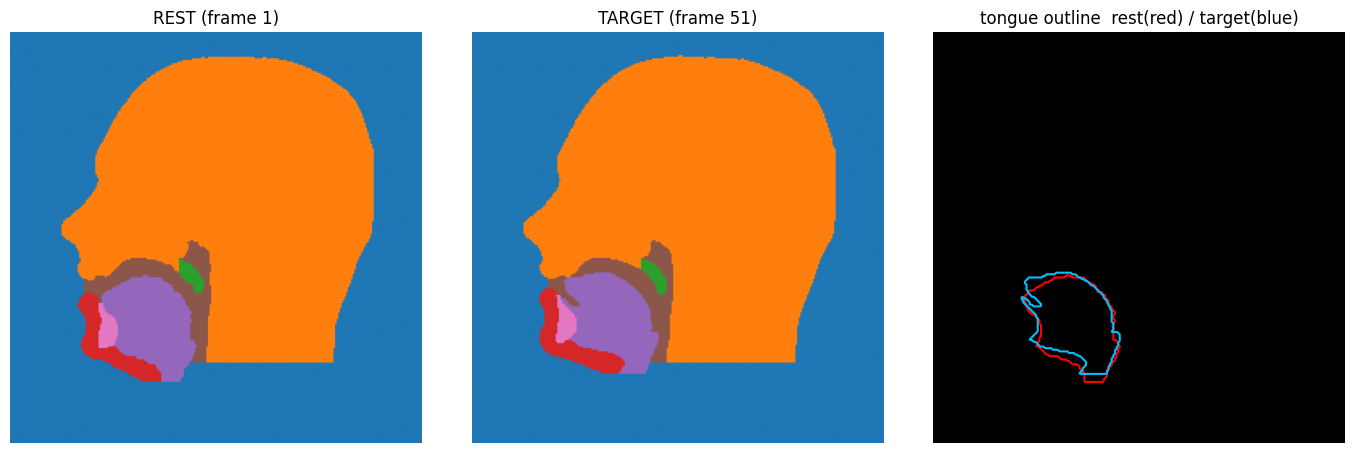

rest: tongue px=2531, airway px=1497
target: tongue px=2431, airway px=1406
🔎 진단: 두 혀 윤곽이 확실히 다르게 움직였는지, tongue/airway 픽셀이 충분한지 확인.


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(14,4.5))
for a,(m,t) in zip(ax[:2], [(rest2d,f"REST (frame {REST_FRAME})"),(tgt2d,f"TARGET (frame {TARGET_FRAME})")]):
    a.imshow(m, cmap="tab10", vmin=0, vmax=9); a.set_title(t); a.axis("off")
# overlay: tongue outline rest(빨강) vs target(파랑)
ax[2].imshow(np.zeros_like(rest2d), cmap="gray")
ax[2].contour(rest2d==LBL_TONGUE, levels=[0.5], colors="red")
ax[2].contour(tgt2d==LBL_TONGUE,  levels=[0.5], colors="deepskyblue")
ax[2].set_title("tongue outline  rest(red) / target(blue)"); ax[2].axis("off")
plt.tight_layout(); plt.show()

for name,m in [("rest",rest2d),("target",tgt2d)]:
    print(f"{name}: tongue px={int((m==LBL_TONGUE).sum())}, airway px={int((m==LBL_AIRWAY).sum())}")
print("🔎 진단: 두 혀 윤곽이 확실히 다르게 움직였는지, tongue/airway 픽셀이 충분한지 확인.")


## 2. Dorsal contour 추출 (`precise_contour` / `mask2contour`)
혀 표면(airway를 향한 등쪽)을 tip→root 순서로 뽑습니다. **가장 흔한 실패 지점**:
- 등쪽이 아니라 아래/옆을 따는 경우
- tip↔root 방향이 뒤집힌 경우
- clip_root 로 너무 많이/적게 잘리는 경우

점 색(보라→노랑)이 tip→root 진행 순서입니다.

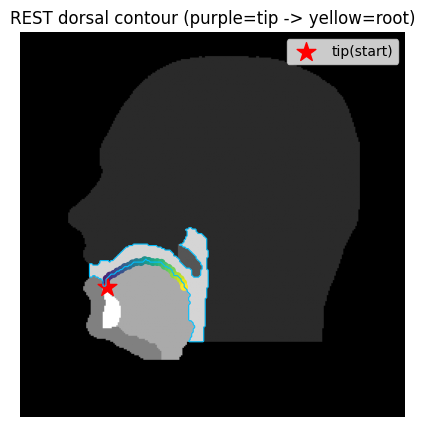

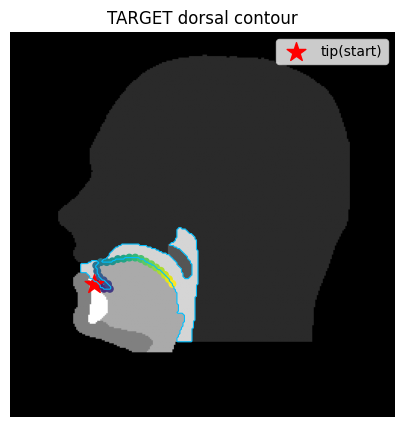

🔎 진단: 빨간 별(tip)이 혀 앞끝에, 점들이 airway(파랑)와 맞닿은 등쪽 표면을 따라가야 정상.
   방향이 뒤집히거나 등쪽이 아니면 여기가 문제입니다.


In [3]:
def show_contour(mask2d, title):
    rc = precise_contour(mask2d, n=25, clip_root=retarget.utils.CLIP_ROOT,
                         clip_drop_frac=retarget.utils.CLIP_DROP_FRAC)
    fig, a = plt.subplots(figsize=(5,5))
    a.imshow(mask2d, cmap="gray")
    a.contour(mask2d==LBL_AIRWAY, levels=[0.5], colors="deepskyblue", linewidths=0.8)
    if rc is not None:
        a.scatter(rc[:,1], rc[:,0], c=np.arange(len(rc)), cmap="viridis", s=22)
        a.scatter(rc[0,1], rc[0,0], marker="*", c="red", s=200, label="tip(start)")
        a.legend(loc="upper right")
    a.set_title(title); a.axis("off"); plt.show()
    return rc

rc_rest = show_contour(rest2d, "REST dorsal contour (purple=tip -> yellow=root)")
rc_tgt  = show_contour(tgt2d,  "TARGET dorsal contour")
print("🔎 진단: 빨간 별(tip)이 혀 앞끝에, 점들이 airway(파랑)와 맞닿은 등쪽 표면을 따라가야 정상.")
print("   방향이 뒤집히거나 등쪽이 아니면 여기가 문제입니다.")


## 3. Registration (image ↔ model affine anchors)
rest 마스크의 해부학적 랜드마크(tip/dorsum/root)와 3D 모델의 대응 랜드마크로
`image-mm → model-mm` affine 을 맞춥니다. **RMS 오차가 크면** 이후 매핑이 전부 틀어집니다.

RMS(mm) = 0.000   worst(mm) = 0.000   anchors=['tip', 'dorsum', 'root']


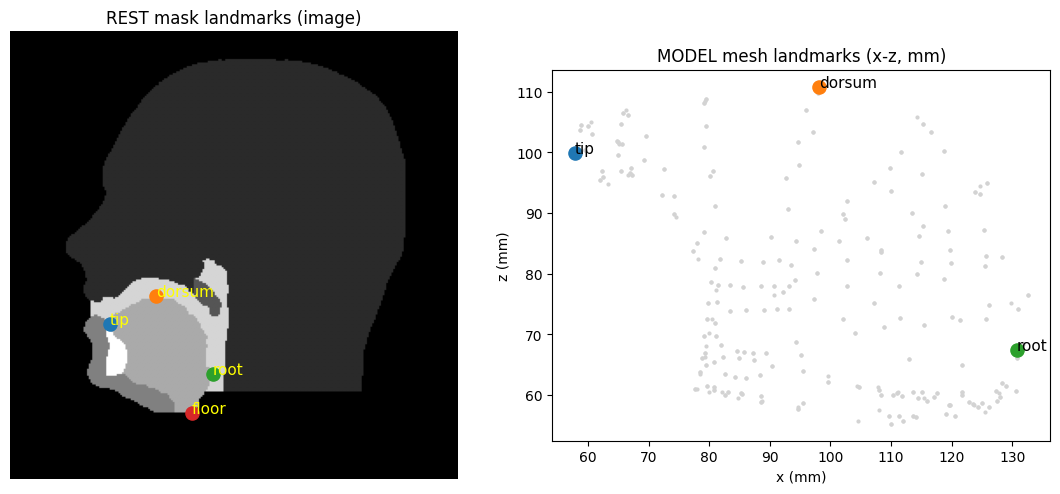

🟩 진단: RMS 0.00mm. 랜드마크(tip/dorsum/root)가 두 그림에서 해부학적으로
   같은 위치를 가리키는지 확인. 어긋나면 registration 이 원인.


In [4]:
ref = TongueModel(); ref.verts = V_rest_m; ref.faces = F
reg_csv = str(REPO/"_test_out"/f"registration_{SUBJECT}.csv")
os.makedirs(os.path.dirname(reg_csv), exist_ok=True)
reg = retarget.register(rest_mask, ref, reg_csv, mm_per_px=MM_PER_PX)
retarget.attach_registration(ref, reg["path"])
print("RMS(mm) = %.3f   worst(mm) = %.3f   anchors=%s" % (reg["rms_mm"], reg["worst_mm"], reg["names"]))

img_lm = image_landmarks_mm(rest_mask, MM_PER_PX)   # image-mm (x,y)
mod_lm = model_landmarks_m(ref)                     # model-m  (x,z)
lm_rc  = anatomical_landmarks(rest2d)               # (row,col) for plotting

fig, ax = plt.subplots(1, 2, figsize=(11,5))
ax[0].imshow(rest2d, cmap="gray")
for k,(r,c) in lm_rc.items():
    ax[0].scatter(c, r, s=90); ax[0].annotate(k, (c,r), color="yellow", fontsize=11)
ax[0].set_title("REST mask landmarks (image)"); ax[0].axis("off")

Vx, Vz = V_rest_m[:,0]*1000, V_rest_m[:,2]*1000
ax[1].scatter(Vx, Vz, s=4, c="lightgray")
for k,(x,z) in mod_lm.items():
    ax[1].scatter(x*1000, z*1000, s=90); ax[1].annotate(k, (x*1000,z*1000), fontsize=11)
ax[1].set_aspect("equal"); ax[1].set_title("MODEL mesh landmarks (x-z, mm)")
ax[1].set_xlabel("x (mm)"); ax[1].set_ylabel("z (mm)"); plt.tight_layout(); plt.show()

flag = "🟥" if reg["rms_mm"] > 5 else ("🟨" if reg["rms_mm"] > 2 else "🟩")
print(f"{flag} 진단: RMS {reg['rms_mm']:.2f}mm. 랜드마크(tip/dorsum/root)가 두 그림에서 해부학적으로")
print("   같은 위치를 가리키는지 확인. 어긋나면 registration 이 원인.")


## 4. 2D contour → model 공간 매핑 (핵심 검증)
affine 으로 rest/target contour 를 모델 좌표(x-z, mm)로 옮겨,
**모델 mesh 및 model_dorsal_curve(제어점) 위에 겹쳐** 그립니다.
매핑된 contour 가 모델 등쪽에 얹혀야 정상입니다.

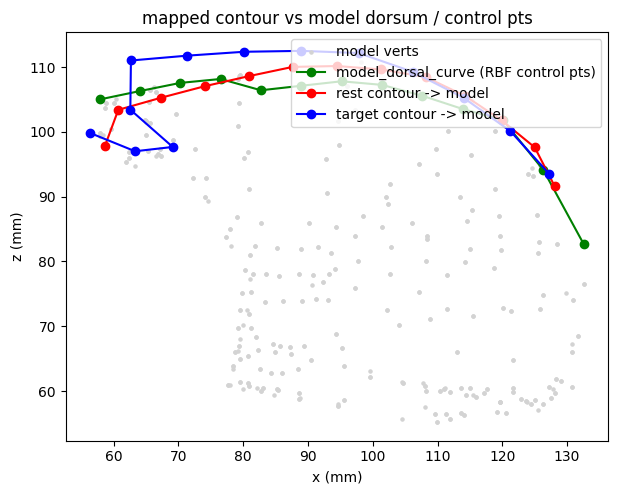

🔎 진단(중요): 빨강(rest)이 회색 모델 등쪽 표면에 얹혀야 함.
   빨강이 모델에서 떨어져 있으면 → registration/좌표 스케일 문제.


In [5]:
to_model = affine_image_to_model(reg["path"])
rest_c   = retarget.mask2contour(rest2d)      # (N,3) image-mm
tgt_c    = retarget.mask2contour(tgt2d)
V_mm     = V_rest_m*1000.0
dorsal   = model_dorsal_curve(V_mm, nb=NCTRL)               # 제어점 위치 (nctrl,2) mm
src_xz   = resample_curve(to_model(rest_c[:,:2]), NCTRL)    # rest contour → model mm
tgt_xz   = resample_curve(to_model(tgt_c[:,:2]),  NCTRL)

fig, a = plt.subplots(figsize=(7,6))
a.scatter(V_mm[:,0], V_mm[:,2], s=5, c="lightgray", label="model verts")
a.plot(dorsal[:,0], dorsal[:,1], "-o", c="green", label="model_dorsal_curve (RBF control pts)")
a.plot(src_xz[:,0], src_xz[:,1], "-o", c="red", label="rest contour -> model")
a.plot(tgt_xz[:,0], tgt_xz[:,1], "-o", c="blue", label="target contour -> model")
a.set_aspect("equal"); a.set_xlabel("x (mm)"); a.set_ylabel("z (mm)")
a.legend(); a.set_title("mapped contour vs model dorsum / control pts"); plt.show()

print("🔎 진단(중요): 빨강(rest)이 회색 모델 등쪽 표면에 얹혀야 함.")
print("   빨강이 모델에서 떨어져 있으면 → registration/좌표 스케일 문제.")


## 5. ⚠️ 제어점 ↔ Δ 대응 정렬 검사
`retarget()` 은 `RBFInterpolator(dorsal, delta)` 로, **위치=`dorsal[k]`** 에
**변위=`delta[k]=target_xz[k]-source_xz[k]`** 를 붙입니다.
그런데 `dorsal` 은 모델 x 를 균등분할해 만든 곡선이고, `source_xz` 는 contour 를
호길이(arc-length)로 리샘플한 것이라 **k번째 점의 위치가 서로 다를 수 있습니다.**
아래에서 `dorsal[k]` 와 `source_xz[k]` 를 선으로 이어 대응이 맞는지 봅니다.

In [23]:
delta = tgt_xz - src_xz
if SPATIAL_WIN > 1 and delta.shape[0] >= SPATIAL_WIN:
    from scipy.ndimage import uniform_filter1d
    delta = uniform_filter1d(delta, SPATIAL_WIN, axis=0, mode="nearest")

fig, a = plt.subplots(figsize=(7,6))
a.scatter(V_mm[:,0], V_mm[:,2], s=5, c="lightgray")
a.plot(dorsal[:,0], dorsal[:,1], "-o", c="green", label="dorsal[k] (where displacement is attached)")
a.plot(src_xz[:,0], src_xz[:,1], "-o", c="red",  label="source_xz[k] (where displacement is measured)")
for k in range(NCTRL):
    a.plot([dorsal[k,0], src_xz[k,0]], [dorsal[k,1], src_xz[k,1]], c="orange", lw=0.8)
a.set_aspect("equal"); a.legend(); a.set_xlabel("x (mm)"); a.set_ylabel("z (mm)")
a.set_title("dorsal[k] <-> source_xz[k] correspondence (orange should be short)"); plt.show()

gap = np.linalg.norm(dorsal - src_xz, axis=1)
print("dorsal[k]–source_xz[k] 거리(mm): mean=%.2f max=%.2f" % (gap.mean(), gap.max()))
flag = "🟥" if gap.mean() > 5 else ("🟨" if gap.mean() > 2 else "🟩")
print(f"{flag} 진단: 주황선(대응 오차)이 길면 → 변위가 엉뚱한 위치에 적용됨(레티게팅 왜곡의 유력 원인).")


dorsal[k]–source_xz[k] 거리(mm): mean=3.68 max=10.02
🟨 진단: 주황선(대응 오차)이 길면 → 변위가 엉뚱한 위치에 적용됨(레티게팅 왜곡의 유력 원인).


## 6. Δ 변위장 & RBF 보간
제어점의 Δ(파랑 화살표)와, 그것을 mesh 전체로 RBF 보간한 정점 변위(회색 화살표)를 봅니다.

In [24]:
from scipy.interpolate import RBFInterpolator
rbf = RBFInterpolator(dorsal, delta, kernel="gaussian",
                      epsilon=1.0/RBF_LEN, degree=-1, smoothing=1e-3)
Vxz = V_mm[:, [0,2]]
d_xz = rbf(Vxz)                        # (Nverts,2) mm

fig, a = plt.subplots(figsize=(7,6))
a.scatter(V_mm[:,0], V_mm[:,2], s=5, c="lightgray")
a.quiver(Vxz[:,0], Vxz[:,1], d_xz[:,0], d_xz[:,1], color="gray",
         angles="xy", scale_units="xy", scale=1, width=0.003, label="vertex displacement (RBF)")
a.quiver(dorsal[:,0], dorsal[:,1], delta[:,0], delta[:,1], color="blue",
         angles="xy", scale_units="xy", scale=1, width=0.005, label="control-pt delta")
a.set_aspect("equal"); a.legend(); a.set_title("displacement field (mm)")
a.set_xlabel("x (mm)"); a.set_ylabel("z (mm)"); plt.show()

print("정점 변위 크기(mm): mean=%.2f max=%.2f" % (
      np.linalg.norm(d_xz,axis=1).mean(), np.linalg.norm(d_xz,axis=1).max()))
print("🔎 진단: 화살표가 target 방향으로 매끄럽게 흐르는지, 폭발/진동하지 않는지 확인(rbf_len/smoothing).")


정점 변위 크기(mm): mean=2.56 max=14.35
🔎 진단: 화살표가 target 방향으로 매끄럽게 흐르는지, 폭발/진동하지 않는지 확인(rbf_len/smoothing).


/tmp/ipykernel_110224/318053667.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, a = plt.subplots(figsize=(7,6))


## 7. 최종 변형 결과
rest(회색) vs 변형(빨강) mesh 를 x-z 로 겹쳐보고, 변위 크기를 컬러맵으로 표시합니다.

In [25]:
V_def = V_rest_m.copy()
V_def[:,0] += d_xz[:,0]/1000.0
V_def[:,2] += d_xz[:,1]/1000.0

fig, ax = plt.subplots(1,2, figsize=(13,6))
ax[0].scatter(V_rest_m[:,0]*1000, V_rest_m[:,2]*1000, s=6, c="lightgray", label="rest")
ax[0].scatter(V_def[:,0]*1000,   V_def[:,2]*1000,   s=6, c="red", label="deformed")
ax[0].set_aspect("equal"); ax[0].legend(); ax[0].set_title("rest vs deformed (x-z, mm)")
ax[0].set_xlabel("x (mm)"); ax[0].set_ylabel("z (mm)")

disp = np.linalg.norm(V_def - V_rest_m, axis=1)*1000
sc = ax[1].scatter(V_def[:,0]*1000, V_def[:,2]*1000, c=disp, cmap="viridis", s=10)
plt.colorbar(sc, ax=ax[1], label="displacement (mm)")
ax[1].set_aspect("equal"); ax[1].set_title("displacement magnitude"); ax[1].set_xlabel("x (mm)"); ax[1].set_ylabel("z (mm)")
plt.tight_layout(); plt.show()
print("변형 변위(mm): mean=%.2f max=%.2f" % (disp.mean(), disp.max()))


변형 변위(mm): mean=2.56 max=14.35


## 8. 실제 `retarget()` 호출과 대조
위에서 손으로 편 단계가 실제 함수와 일치하는지 확인(불일치 시 코드 경로가 다른 것).

In [26]:
obj = retarget.retarget(ref, rest_mask, target_mask,
                        nctrl=NCTRL, rbf_len=RBF_LEN, spatial_win=SPATIAL_WIN)
diff = np.abs(obj["points_cloud"] - V_def).max()
print("manual vs retarget() 최대 차이:", diff, "(≈0 이어야 정상)")
print("points_cloud", obj["points_cloud"].shape, "Color", obj["Color"].shape)


manual vs retarget() 최대 차이: 0.0 (≈0 이어야 정상)
points_cloud (433, 3) Color (433, 3)


---
### 요약 체크리스트
1. **1단계** rest/target 자세가 실제로 다른가?
2. **2단계** dorsal contour 가 등쪽을 tip→root 로 올바르게 따는가?
3. **3단계** registration RMS 가 작은가(🟩)? 랜드마크가 해부학적으로 대응하는가?
4. **4단계** 매핑된 rest contour 가 모델 등쪽에 얹히는가?
5. **5단계** `dorsal[k]` 와 `source_xz[k]` 대응이 정렬돼 있는가? (주황선 짧은가)
6. **6~7단계** 변위장이 매끄럽고 target 방향인가?

가장 의심스러운 단계의 셀만 반복 실행하며 파라미터(`MM_PER_PX`, `NCTRL`,
`RBF_LEN`, `clip_root`)를 바꿔 원인을 좁혀가세요.
